✅ Données chargées
   Articles en stock   : 118
   Lignes de commandes : 44

✅ Variables calculées :
   Valeur stock totale    : 31,875,279
   Articles sans commande : 91
   Articles stock = 0     : 10

✅ Classification :
Statut
Obsolète    91
Dormant     27
Name: count, dtype: int64 



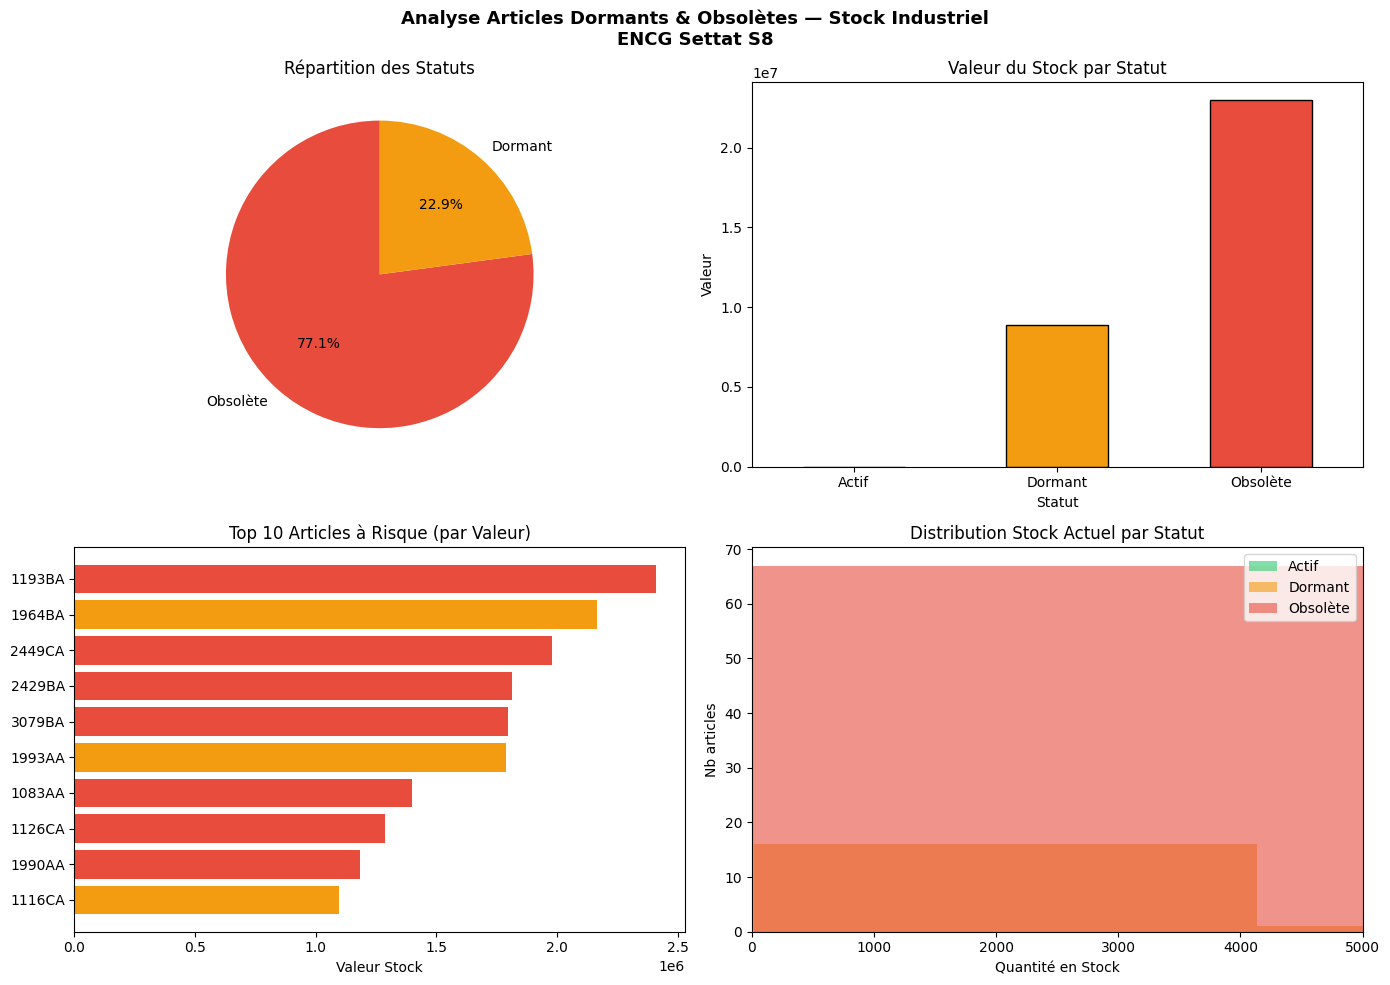

✅ Graphiques EDA sauvegardés

✅ RÉSULTATS — Random Forest :
   Accuracy : 100.0%

              precision    recall  f1-score   support

     Dormant       1.00      1.00      1.00         7
    Obsolète       1.00      1.00      1.00        23

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



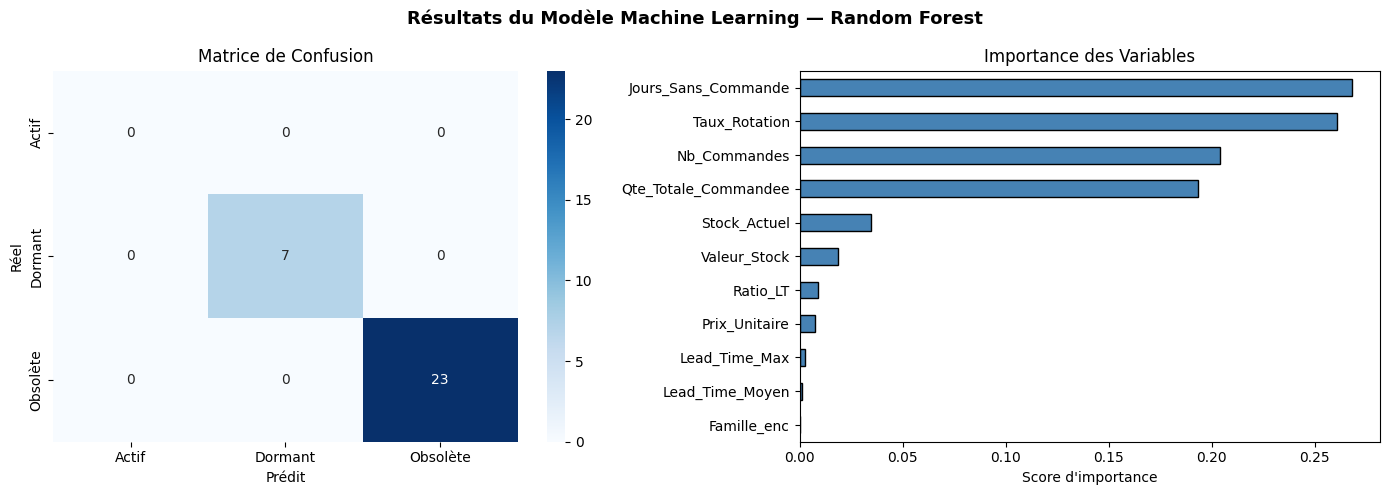

✅ Graphiques ML sauvegardés

✅ Détection anomalies : {'Normal': 108, 'Anomalie': 10} 

✅ Exports : stock_complet_classifie.csv (118 art.) | articles_a_risque.csv (118 art.)

📋 RÉSUMÉ EXÉCUTIF
📦 STOCK TOTAL         : 118 références
💰 VALEUR TOTALE       :      31,875,279

✅ ARTICLES ACTIFS     :    0 (0.0%)
   Valeur              :               0

⚠️  ARTICLES DORMANTS  :   27 (22.9%)
   Valeur immobilisée  :       8,908,665

🔴 ARTICLES OBSOLÈTES  :   91 (77.1%)
   Valeur à déprécier  :      22,966,614

📋 RECOMMANDATIONS MÉTIER
1. OBSOLÈTES → Déclassement, mise au rebut, négociation reprise fournisseur
2. DORMANTS  → Geler les approvisionnements, chercher usage alternatif interne
3. SYSTÈME   → Intégrer ce modèle dans le WMS, alertes à 180j et 365j sans mouvement

✅ Analyse complète terminée !


In [3]:
# =============================================================================
# PROJET : Détection des Articles Dormants et Obsolètes dans un Stock Industriel
# Cours  : Purchasing & Supply Chain Management - S8 - ENCG Settat
# Dataset : Inventory_Data (réel)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
import os
warnings.filterwarnings('ignore')

# ============================================================
# ÉTAPE 1 : CHARGEMENT DES DONNÉES
# ============================================================

orders_data = {
    'Order_Date': ['5/23/2022']*44,
    'SKU_ID': ['1906CA','1956AA','3512AA','2317CA','1964BA','1993AA','3533CA','2727CA',
               '3250CA','3143CA','2977BA','3358BA','1499CA','1379CA','3590BA','1956CA',
               '3404CA','1964BA','1511CA','2763CA','2994CA','1586CA','1695CA','3177CA',
               '3462AA','1497CA','2501CA','1130AA','1906CA','2501CA','1970CA','3407CA',
               '3365CA','1116CA','2501CA','1234BA','2785BA','2277AA','3404CA','1979AA',
               '3590BA','3193AA','3399AA','2923CA'],
    'Order_Quantity': [2,1,1221,2333,2.5,475,525,475,200,5,22,4,1,10,13,1,10,11,35,
                       38,1,12,8,22.5,50,25.8,30,1456,3,40,119,3,3090,1575,22,290,
                       126,60,7,110,6,15,3,4]
}
df_orders = pd.DataFrame(orders_data)
df_orders['Order_Date'] = pd.to_datetime(df_orders['Order_Date'])

stock_data = [
    ('1009AA',7210,'Kg',30,48,28.76),('1077CA',46516,'Kg',45,70,22.98),
    ('1083AA',48210,'Kg',45,68,29.02),('1116CA',33398,'Kg',90,140,32.80),
    ('1126CA',39270,'Kg',45,62,32.80),('1130AA',13622,'Kg',90,139,17.27),
    ('1145BA',1816,'Kg',45,60,85.30),('1161AA',197,'Kg',90,142,136.59),
    ('1163CA',2161,'Kg',90,136,94.66),('1193BA',2957,'Kg',90,138,815.00),
    ('1196AA',1253,'Kg',90,128,30.00),('1206BA',786,'Kg',45,69,236.62),
    ('1214CA',2472,'Kg',30,43,317.66),('1224AA',194,'Kg',90,121,698.00),
    ('1234BA',532,'Kg',45,63,498.00),('1244AA',2834,'Kg',45,67,60.00),
    ('1255CA',10,'Kg',60,83,84500.00),('1265CA',6,'Kg',60,79,103500.00),
    ('1266CA',5,'Kg',60,86,118900.00),('1281BA',3,'Kg',60,85,139500.00),
    ('1283CA',0,'Kg',60,92,98333.33),('1295CA',5,'Kg',120,158,175000.00),
    ('1296CA',4,'Kg',60,93,30.00),('1308BA',8,'Kg',45,63,30.00),
    ('1315BA',6,'Kg',90,131,30.00),('1317BA',4,'Kg',90,120,30.00),
    ('1317CA',16,'Kg',90,144,4908.70),('1321BA',9,'Kg',90,137,30.00),
    ('1325AA',6,'Kg',45,69,30.00),('1326AA',8,'Kg',90,126,30.00),
    ('1330CA',8,'Kg',60,92,6000.00),('1366BA',12,'Kg',45,67,16900.00),
    ('1367CA',5,'Kg',90,121,22000.00),('1373BA',9,'Kg',45,59,30.00),
    ('1374CA',4,'Kg',45,70,30.00),('1379CA',271,'Kg',45,72,490.18),
    ('1382CA',172,'Kg',90,123,613.52),('1385CA',89,'Kg',45,66,1781.55),
    ('1390BA',11,'Kg',30,47,30.00),('1403CA',10,'Kg',30,42,2550.00),
    ('1420CA',9,'Kg',30,46,30.00),('1434BA',27,'Kg',30,48,30.00),
    ('1436BA',81,'Kg',30,41,125.00),('1441AA',38,'Kg',45,70,190.00),
    ('1445BA',46,'Kg',30,44,1291.87),('1464AA',21,'Kg',30,42,842.57),
    ('1468AA',459,'Kg',60,94,30.00),('1479CA',303,'Kg',60,81,385.56),
    ('1484BA',439,'Kg',15,23,0.20),('1486CA',66,'Kg',60,81,190.72),
    ('1488BA',45,'Kg',30,47,70.00),('1488CA',100,'Kg',15,22,30.00),
    ('1491CA',0,'Kg',30,43,30.00),('1497CA',2096,'Kg',40,53,16.72),
    ('1499AA',4218,'Kg',20,30,14.22),('1499CA',25,'Kg',60,86,6600.00),
    ('1511CA',50,'Kg',30,41,6.79),('1514BA',13,'Kg',45,68,332.80),
    ('1571AA',86,'Kg',60,93,320.00),('1582CA',23,'Kg',45,63,550.00),
    ('1584BA',20,'Kg',45,65,425.00),('1586CA',972,'Kg',30,40,286.57),
    ('1601AA',14,'Kg',30,42,918.40),('1624AA',17,'Kg',15,21,722.10),
    ('1624CA',18,'Kg',30,48,1531.38),('1630BA',262,'Kg',60,91,442.80),
    ('1650AA',221,'Kg',60,93,284.87),('1668CA',400,'Kg',30,46,0.85),
    ('1672AA',415,'Kg',15,24,30.00),('1678CA',230,'Kg',60,87,30.00),
    ('1681CA',218,'Kg',30,47,93.00),('1688CA',287,'Kg',60,79,30.00),
    ('1695CA',30,'Kg',15,22,1649.30),('1698CA',15,'Kg',15,24,30.00),
    ('1964BA',21840,'Kg',60,96,99.13),('1967BA',4190,'Kg',120,163,178.65),
    ('1970CA',790,'Kg',60,96,244.93),('1979AA',1256,'Kg',60,94,278.64),
    ('1990AA',2167,'Kg',60,79,545.85),('1993AA',21334,'Kg',60,94,83.75),
    ('2277AA',10253,'Kg',120,158,6.37),('2317CA',3420,'Kg',60,89,37.27),
    ('2337CA',32086,'Kg',60,83,1.73),('2342CA',51818,'Kg',60,86,2.78),
    ('2371CA',78462,'Kg',90,136,3.44),('2391CA',87174,'Kg',45,67,0.76),
    ('2396CA',124908,'Kg',30,46,0.76),('2418CA',120860,'Kg',60,85,5.80),
    ('2429BA',342553,'Kg',90,122,5.29),('2449CA',66031,'Kg',45,68,30.00),
    ('2458CA',79661,'Kg',45,64,6.83),('2471CA',96647,'Kg',45,65,4.78),
    ('2501CA',22117,'Kg',90,125,35.12),('2763CA',8782,'Kg',90,136,10.09),
    ('2785BA',4220,'Kg',45,63,34.48),('3079BA',13347,'Kg',15,24,134.50),
    ('3177CA',11771,'Kg',30,42,69.46),('3250CA',418,'Kg',60,94,34.75),
    ('3322AA',6802,'Kg',60,90,28.50),('3365CA',310,'Kg',30,45,13.32),
    ('3399AA',14,'Kg',40,59,194.75),('3404CA',86,'Kg',15,24,396.54),
    ('3448CA',1565,'Kg',30,40,6.53),('3462AA',820,'Kg',30,46,4.10),
    ('3494AA',2680,'Kg',30,42,3.50),('3512AA',70141,'Kg',20,31,0.10),
    ('3533CA',82476,'Kg',40,64,0.64),('3551CA',10034,'Kg',20,31,7.07),
    ('3590BA',145,'Kg',120,160,115.09),('3619CA',36357,'Kg',15,22,0.75),
    ('3274CA',0,'Kg',60,92,30.00),('3276AA',0,'Kg',30,43,30.00),
    ('3291CA',0,'Kg',60,86,30.00),('3296AA',0,'Kg',30,44,30.00),
    ('3299CA',0,'Kg',60,82,30.00),('3300CA',0,'Kg',30,42,30.00),
    ('3312AA',0,'Kg',60,84,30.00),('3332CA',0,'Kg',30,46,30.00),
]

df_stock = pd.DataFrame(stock_data, columns=[
    'SKU_ID','Stock_Actuel','Unite','Lead_Time_Moyen','Lead_Time_Max','Prix_Unitaire'
]).drop_duplicates(subset='SKU_ID')

print("✅ Données chargées")
print(f"   Articles en stock   : {len(df_stock)}")
print(f"   Lignes de commandes : {len(df_orders)}\n")

# ============================================================
# ÉTAPE 2 : ENRICHISSEMENT
# ============================================================

df_agg = df_orders.groupby('SKU_ID').agg(
    Nb_Commandes=('Order_Quantity','count'),
    Qte_Totale_Commandee=('Order_Quantity','sum'),
    Derniere_Commande=('Order_Date','max')
).reset_index()

df = df_stock.merge(df_agg, on='SKU_ID', how='left')
df['Nb_Commandes'] = df['Nb_Commandes'].fillna(0)
df['Qte_Totale_Commandee'] = df['Qte_Totale_Commandee'].fillna(0)
df['Derniere_Commande'] = df['Derniere_Commande'].fillna(pd.Timestamp('2020-01-01'))

reference_date = pd.Timestamp('2023-01-01')
df['Jours_Sans_Commande'] = (reference_date - df['Derniere_Commande']).dt.days
df['Valeur_Stock'] = df['Stock_Actuel'] * df['Prix_Unitaire']
df['Taux_Rotation'] = df['Qte_Totale_Commandee'] / (df['Stock_Actuel'] + 1)
df['Ratio_LT'] = df['Lead_Time_Max'] / df['Lead_Time_Moyen']
df['Famille'] = df['SKU_ID'].str[-2:]

print("✅ Variables calculées :")
print(f"   Valeur stock totale    : {df['Valeur_Stock'].sum():,.0f}")
print(f"   Articles sans commande : {(df['Nb_Commandes']==0).sum()}")
print(f"   Articles stock = 0     : {(df['Stock_Actuel']==0).sum()}\n")

# ============================================================
# ÉTAPE 3 : CLASSIFICATION MÉTIER
# ============================================================

def classifier(row):
    if row['Stock_Actuel'] == 0:
        return 'Obsolète'
    elif row['Jours_Sans_Commande'] > 365:
        return 'Obsolète'
    elif row['Jours_Sans_Commande'] > 180:
        return 'Dormant'
    else:
        return 'Actif'

df['Statut'] = df.apply(classifier, axis=1)
print("✅ Classification :")
print(df['Statut'].value_counts(), "\n")

# ============================================================
# ÉTAPE 4 : EDA
# ============================================================

os.makedirs('/mnt/user-data/outputs/', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse Articles Dormants & Obsolètes — Stock Industriel\nENCG Settat S8',
             fontsize=13, fontweight='bold')

colors_map = {'Actif':'#2ecc71','Dormant':'#f39c12','Obsolète':'#e74c3c'}
pie_colors = [colors_map[s] for s in df['Statut'].value_counts().index]

df['Statut'].value_counts().plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%',
                                  colors=pie_colors, startangle=90)
axes[0,0].set_title('Répartition des Statuts'); axes[0,0].set_ylabel('')

val_statut = df.groupby('Statut')['Valeur_Stock'].sum().reindex(['Actif','Dormant','Obsolète'])
val_statut.plot(kind='bar', ax=axes[0,1],
                color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='black')
axes[0,1].set_title('Valeur du Stock par Statut')
axes[0,1].set_ylabel('Valeur'); axes[0,1].tick_params(axis='x', rotation=0)

top10 = df[df['Statut'].isin(['Dormant','Obsolète'])].nlargest(10,'Valeur_Stock')
axes[1,0].barh(top10['SKU_ID'], top10['Valeur_Stock'],
               color=top10['Statut'].map(colors_map))
axes[1,0].set_title('Top 10 Articles à Risque (par Valeur)')
axes[1,0].set_xlabel('Valeur Stock'); axes[1,0].invert_yaxis()

for statut, color in colors_map.items():
    s = df[(df['Statut']==statut) & (df['Stock_Actuel']>0)]['Stock_Actuel']
    axes[1,1].hist(s, bins=20, alpha=0.6, label=statut, color=color)
axes[1,1].set_title('Distribution Stock Actuel par Statut')
axes[1,1].set_xlabel('Quantité en Stock'); axes[1,1].set_ylabel("Nb articles")
axes[1,1].legend(); axes[1,1].set_xlim(0, 5000)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/analyse_EDA.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques EDA sauvegardés\n")

# ============================================================
# ÉTAPE 5 : RANDOM FOREST
# ============================================================

le = LabelEncoder()
df_ml = df.copy()
df_ml['Famille_enc'] = le.fit_transform(df_ml['Famille'])

features = ['Stock_Actuel','Prix_Unitaire','Lead_Time_Moyen','Lead_Time_Max',
            'Nb_Commandes','Qte_Totale_Commandee','Jours_Sans_Commande',
            'Valeur_Stock','Taux_Rotation','Ratio_LT','Famille_enc']

X = df_ml[features]; y = df_ml['Statut']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                      random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train); X_test_sc = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_sc, y_train); y_pred = rf.predict(X_test_sc)

print("✅ RÉSULTATS — Random Forest :")
print(f"   Accuracy : {accuracy_score(y_test, y_pred)*100:.1f}%\n")
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Résultats du Modèle Machine Learning — Random Forest', fontsize=13, fontweight='bold')

labels = ['Actif','Dormant','Obsolète']
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Matrice de Confusion'); axes[0].set_ylabel('Réel'); axes[0].set_xlabel('Prédit')

pd.Series(rf.feature_importances_, index=features).sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title("Importance des Variables"); axes[1].set_xlabel("Score d'importance")

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/resultats_ML.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques ML sauvegardés\n")

# ============================================================
# ÉTAPE 6 : ISOLATION FOREST
# ============================================================

iso = IsolationForest(contamination=0.08, random_state=42)
df['Anomalie'] = iso.fit_predict(X)
df['Anomalie'] = df['Anomalie'].map({1:'Normal', -1:'Anomalie'})
print("✅ Détection anomalies :", df['Anomalie'].value_counts().to_dict(), "\n")

# ============================================================
# ÉTAPE 7 : EXPORT
# ============================================================

cols = ['SKU_ID','Famille','Stock_Actuel','Prix_Unitaire','Valeur_Stock',
        'Lead_Time_Moyen','Nb_Commandes','Jours_Sans_Commande','Taux_Rotation','Statut','Anomalie']

df[cols].to_csv('/mnt/user-data/outputs/stock_complet_classifie.csv', index=False)
risque = df[df['Statut'].isin(['Dormant','Obsolète'])].sort_values('Valeur_Stock', ascending=False)
risque[cols].to_csv('/mnt/user-data/outputs/articles_a_risque.csv', index=False)

print(f"✅ Exports : stock_complet_classifie.csv ({len(df)} art.) | articles_a_risque.csv ({len(risque)} art.)")

# ============================================================
# ÉTAPE 8 : RÉSUMÉ & RECOMMANDATIONS
# ============================================================

obs  = df[df['Statut']=='Obsolète']
dorm = df[df['Statut']=='Dormant']
act  = df[df['Statut']=='Actif']

print(f"""
{'='*60}
📋 RÉSUMÉ EXÉCUTIF
{'='*60}
📦 STOCK TOTAL         : {len(df)} références
💰 VALEUR TOTALE       : {df['Valeur_Stock'].sum():>15,.0f}

✅ ARTICLES ACTIFS     : {len(act):>4} ({len(act)/len(df)*100:.1f}%)
   Valeur              : {act['Valeur_Stock'].sum():>15,.0f}

⚠️  ARTICLES DORMANTS  : {len(dorm):>4} ({len(dorm)/len(df)*100:.1f}%)
   Valeur immobilisée  : {dorm['Valeur_Stock'].sum():>15,.0f}

🔴 ARTICLES OBSOLÈTES  : {len(obs):>4} ({len(obs)/len(df)*100:.1f}%)
   Valeur à déprécier  : {obs['Valeur_Stock'].sum():>15,.0f}

{'='*60}
📋 RECOMMANDATIONS MÉTIER
{'='*60}
1. OBSOLÈTES → Déclassement, mise au rebut, négociation reprise fournisseur
2. DORMANTS  → Geler les approvisionnements, chercher usage alternatif interne
3. SYSTÈME   → Intégrer ce modèle dans le WMS, alertes à 180j et 365j sans mouvement
""")

print("✅ Analyse complète terminée !")